In [16]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.model_selection import train_test_split

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D,
    Conv1D, MaxPooling1D,
    GlobalAveragePooling1D,
    Flatten, Dense, Input,
    BatchNormalization, Dropout
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow :", tf.__version__)
print("Librosa    :", librosa.__version__)

TensorFlow : 2.20.0
Librosa    : 0.11.0


In [2]:
# spoken_digit ships only a 'train' split in TFDS – we create val/test ourselves
ds, info = tfds.load('spoken_digit', split='train', with_info=True)

print(info.description)
print()
print("Features :", info.features)
print("Samples  :", info.splits['train'].num_examples)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


Shuffling /root/tensorflow_datasets/spoken_digit/incomplete.Q5LT0U_1.0.9/spoken_digit-train.tfrecord*...:   0%…

Dataset spoken_digit downloaded and prepared to /root/tensorflow_datasets/spoken_digit/1.0.9. Subsequent calls will reuse this data.
A free audio dataset of spoken digits. Think MNIST for audio.

A simple audio/speech dataset consisting of recordings of spoken digits in wav
files at 8kHz.
The recordings are trimmed so that they have near minimal silence at the
beginnings and ends.

5 speakers\
2,500 recordings (50 of each digit per speaker)\
English pronunciations

Files are named in the following format: {digitLabel}_{speakerName}_{index}.wav

Features : FeaturesDict({
    'audio': Audio(shape=(None,), dtype=int64),
    'audio/filename': Text(shape=(), dtype=string),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
})
Samples  : 2500


In [3]:
SAMPLE_RATE = 8000

raw_lengths = []
raw_labels  = []
raw_audios_preview = {}   # one sample per digit for visualisation

for example in ds:
    audio = tf.cast(example['audio'], tf.float32).numpy()
    label = int(example['label'].numpy())
    raw_lengths.append(len(audio))
    raw_labels.append(label)
    if label not in raw_audios_preview:
        raw_audios_preview[label] = audio

raw_lengths = np.array(raw_lengths)
raw_labels  = np.array(raw_labels)

print("=== Sample Length Statistics ===")
print(f"  Min  : {raw_lengths.min():>6} samples  ({raw_lengths.min()/SAMPLE_RATE:.3f} s)")
print(f"  Max  : {raw_lengths.max():>6} samples  ({raw_lengths.max()/SAMPLE_RATE:.3f} s)")
print(f"  Mean : {raw_lengths.mean():>6.0f} samples  ({raw_lengths.mean()/SAMPLE_RATE:.3f} s)")
print(f"  Std  : {raw_lengths.std():>6.0f} samples")
print()
print("=== Class Distribution ===")
for digit, count in sorted(Counter(raw_labels).items()):
    print(f"  Digit {digit}: {count} samples")

=== Sample Length Statistics ===
  Min  :   1148 samples  (0.143 s)
  Max  :  18262 samples  (2.283 s)
  Mean :   3281 samples  (0.410 s)
  Std  :   1026 samples

=== Class Distribution ===
  Digit 0: 250 samples
  Digit 1: 250 samples
  Digit 2: 250 samples
  Digit 3: 250 samples
  Digit 4: 250 samples
  Digit 5: 250 samples
  Digit 6: 250 samples
  Digit 7: 250 samples
  Digit 8: 250 samples
  Digit 9: 250 samples


In [5]:
SAMPLE_RATE  = 8000
FIXED_LENGTH = 8000   # 1 second – pads short clips, truncates long ones
N_MFCC       = 40
HOP_LENGTH   = 128

X_raw  = []   # fixed-length waveform  (for 1D CNN)
X_mfcc = []   # MFCC feature map       (for 2D CNN)
y      = []

for example in ds:
    audio = tf.cast(example['audio'], tf.float32).numpy()
    label = int(example['label'].numpy())

    # Amplitude normalisation
    max_val = np.max(np.abs(audio))
    if max_val > 0:
        audio = audio / max_val

    # Fix length: zero-pad or truncate  ← solves the variable-length problem
    audio_fixed = librosa.util.fix_length(audio, size=FIXED_LENGTH)

    # MFCC extraction  → shape (N_MFCC, time_frames)
    mfcc = librosa.feature.mfcc(
        y=audio_fixed, sr=SAMPLE_RATE,
        n_mfcc=N_MFCC, hop_length=HOP_LENGTH
    )

    X_raw.append(audio_fixed)
    X_mfcc.append(mfcc)
    y.append(label)

X_raw  = np.array(X_raw,  dtype=np.float32)
X_mfcc = np.array(X_mfcc, dtype=np.float32)
y      = np.array(y,       dtype=np.int32)

# Global MFCC standardisation (zero-mean, unit-variance)
global_mean = X_mfcc.mean()
global_std  = X_mfcc.std()
X_mfcc = (X_mfcc - global_mean) / (global_std + 1e-8)

print(f"Total samples  : {len(X_raw)}")
print(f"Raw audio shape: {X_raw.shape}   (samples × time)")
print(f"MFCC shape     : {X_mfcc.shape}  (samples × coefficients × frames)")
print(f"MFCC mean: {X_mfcc.mean():.4f}   std: {X_mfcc.std():.4f}")

Total samples  : 2500
Raw audio shape: (2500, 8000)   (samples × time)
MFCC shape     : (2500, 40, 63)  (samples × coefficients × frames)
MFCC mean: 0.0000   std: 1.0000


/tmp/ipykernel_2350/4221355989.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


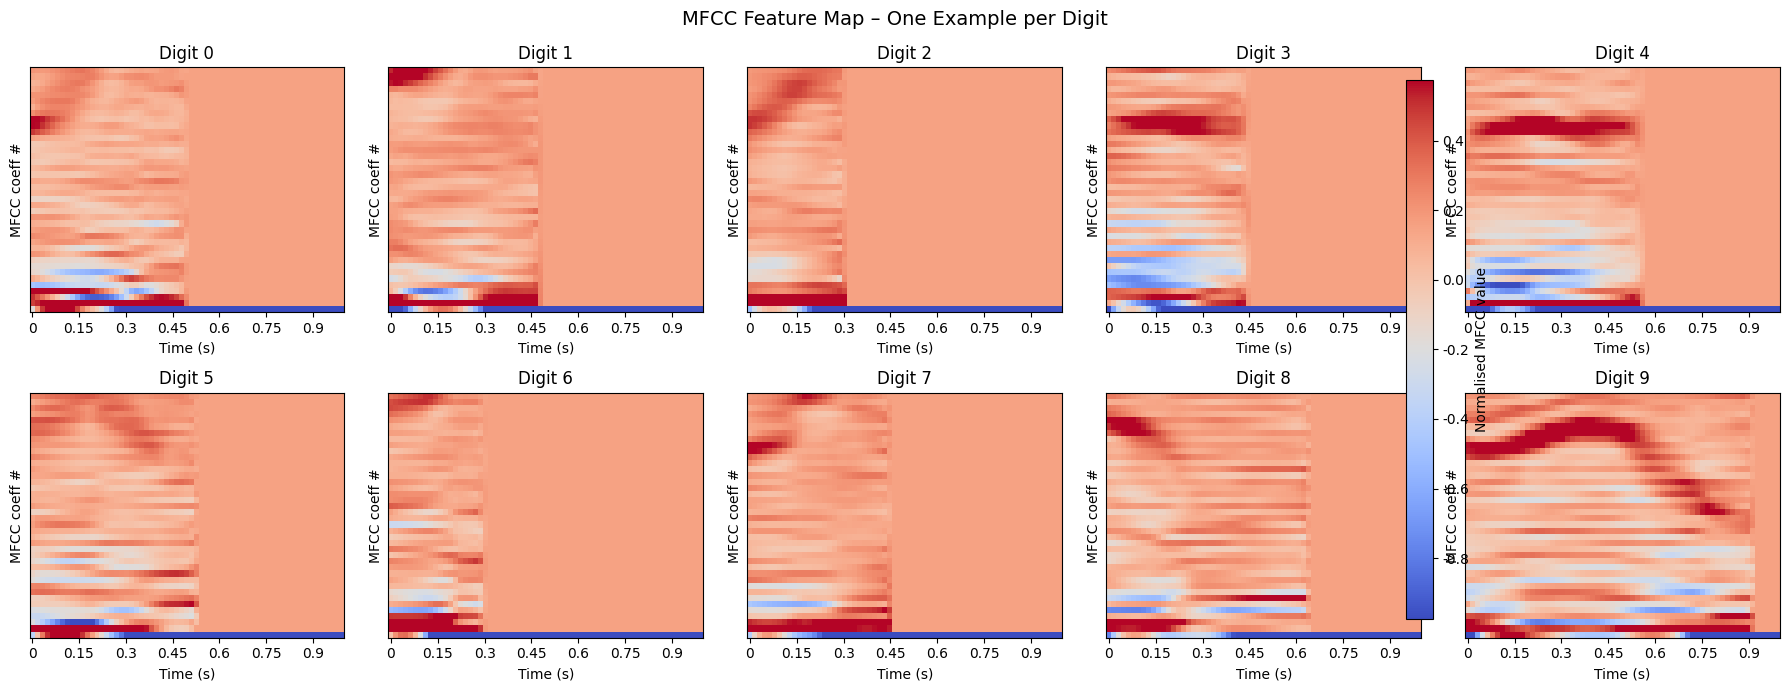

In [6]:
# Visualise MFCC feature maps for one sample per digit
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('MFCC Feature Map – One Example per Digit', fontsize=14)

vmin = np.percentile(X_mfcc, 2)
vmax = np.percentile(X_mfcc, 98)

for digit in range(10):
    ax  = axes[digit // 5][digit % 5]
    idx = np.where(y == digit)[0][0]
    img = librosa.display.specshow(
        X_mfcc[idx], sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
        x_axis='time', ax=ax, cmap='coolwarm',
        vmin=vmin, vmax=vmax
    )
    ax.set_title(f'Digit {digit}')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('MFCC coeff #')

fig.colorbar(img, ax=axes, format='%.1f', label='Normalised MFCC value')
plt.tight_layout()
plt.show()

## 4 · Train / Validation / Test Split

Using stratified splitting to preserve class ratios in all three sets:
- **80 %** train  
- **10 %** validation (used during training for early stopping)  
- **10 %** test (held-out; evaluated only after training is complete)

In [7]:
# Step 1 – carve off 10% test
X_raw_temp, X_raw_test, X_mfcc_temp, X_mfcc_test, y_temp, y_test = train_test_split(
    X_raw, X_mfcc, y,
    test_size=0.10, random_state=42, stratify=y
)

# Step 2 – split remaining 90% → 80% train / 10% val  (0.10/0.90 ≈ 0.1111)
X_raw_train, X_raw_val, X_mfcc_train, X_mfcc_val, y_train, y_val = train_test_split(
    X_raw_temp, X_mfcc_temp, y_temp,
    test_size=0.1111, random_state=42, stratify=y_temp
)

# Add channel dimension required by Conv2D (2D CNN) and Conv1D (1D CNN)
X_mfcc_train = X_mfcc_train[..., np.newaxis]   # (N, coeff, frames, 1)
X_mfcc_val   = X_mfcc_val[..., np.newaxis]
X_mfcc_test  = X_mfcc_test[..., np.newaxis]

X_raw_train  = X_raw_train[..., np.newaxis]    # (N, time, 1)
X_raw_val    = X_raw_val[..., np.newaxis]
X_raw_test   = X_raw_test[..., np.newaxis]

n_total = len(X_raw)
print(f"Train : {X_raw_train.shape[0]:>4} samples  ({X_raw_train.shape[0]/n_total*100:.0f}%)")
print(f"Val   : {X_raw_val.shape[0]:>4} samples  ({X_raw_val.shape[0]/n_total*100:.0f}%)")
print(f"Test  : {X_raw_test.shape[0]:>4} samples  ({X_raw_test.shape[0]/n_total*100:.0f}%)")
print()
print(f"MFCC train shape : {X_mfcc_train.shape}")
print(f"Raw  train shape : {X_raw_train.shape}")

Train : 2000 samples  (80%)
Val   :  250 samples  (10%)
Test  :  250 samples  (10%)

MFCC train shape : (2000, 40, 63, 1)
Raw  train shape : (2000, 8000, 1)


In [36]:
input_shape_2d = X_mfcc_train.shape[1:]

model_2d = Sequential([
    Input(shape=input_shape_2d),

    Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same',
           kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
     Dropout(0.3),

    Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same',
           kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),

    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.3),
    Dense(10, activation='softmax')
], name='2D_CNN_MFCC')


model_2d.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_2d.summary()

Model: "2D_CNN_MFCC"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 40, 63, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 40, 63, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 20, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 20, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 20, 31, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 20, 31, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 10, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 10, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 9600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │     1,228,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,249,418 (4.77 MB)

 Trainable params: 1,249,226 (4.77 MB)

 Non-trainable params: 192 (768.00 B)

In [37]:
early_stop_2d = EarlyStopping(
    monitor='val_accuracy', patience=5,
    restore_best_weights=True, verbose=1
)

history_2d = model_2d.fit(
    X_mfcc_train, y_train,
    validation_data=(X_mfcc_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop_2d],
    verbose=1
)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 12s 88ms/step - accuracy: 0.2665 - loss: 2.3049 - val_accuracy: 0.2000 - val_loss: 2.2518
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5520 - loss: 1.2619 - val_accuracy: 0.1520 - val_loss: 2.1115
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7450 - loss: 0.7607 - val_accuracy: 0.4760 - val_loss: 1.8205
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8210 - loss: 0.5354 - val_accuracy: 0.4360 - val_loss: 1.6705
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8705 - loss: 0.4021 - val_accuracy: 0.5520 - val_loss: 1.2859
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8995 - loss: 0.3321 - val_accuracy: 0.7600 - val_loss: 0.8253
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9175 - loss: 0.2770 - val_accuracy: 0.8440 - val_loss: 0.5658
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9345 - loss: 0.2244 - val_accuracy: 0.8920 - val_lo

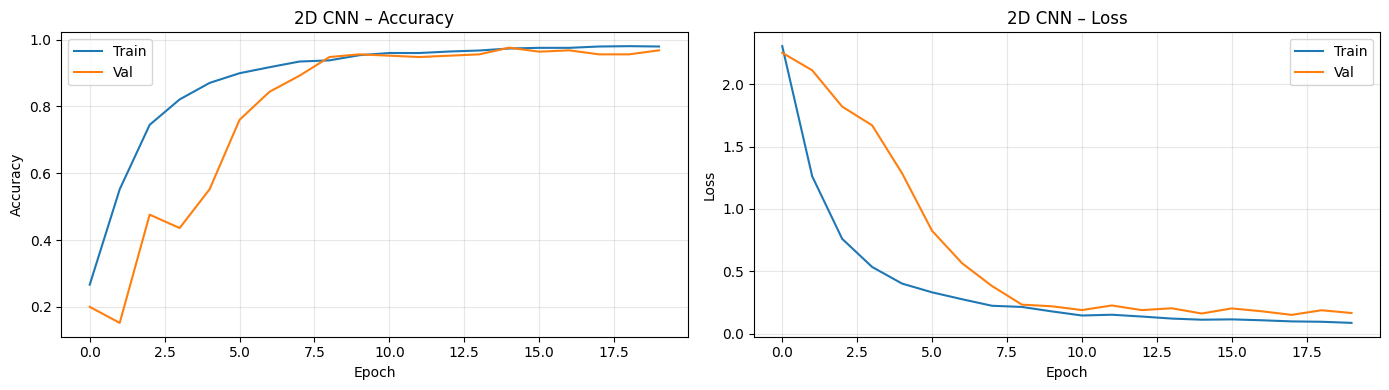


2D CNN  →  Test Loss: 0.0849  |  Test Accuracy: 98.80%


In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history_2d.history['accuracy'],     label='Train')
ax1.plot(history_2d.history['val_accuracy'], label='Val')
ax1.set_title('2D CNN – Accuracy'); ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history_2d.history['loss'],     label='Train')
ax2.plot(history_2d.history['val_loss'], label='Val')
ax2.set_title('2D CNN – Loss'); ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

test_loss_2d, test_acc_2d = model_2d.evaluate(X_mfcc_test, y_test, verbose=0)
print(f"\n2D CNN  →  Test Loss: {test_loss_2d:.4f}  |  Test Accuracy: {test_acc_2d*100:.2f}%")

In [65]:
input_shape_1d = X_raw_train.shape[1:]

model_1d = Sequential([
    Input(shape=input_shape_1d),

    Conv1D(32,  kernel_size=80, activation='relu', padding='same'),   # ~10 ms
    BatchNormalization(),
    MaxPooling1D(pool_size=4),
    Dropout(0.2),

    Conv1D(64,  kernel_size=40, activation='relu', padding='same'),   # ~5 ms
    BatchNormalization(),
    MaxPooling1D(pool_size=4),
    Dropout(0.2),

    Conv1D(128, kernel_size=20, activation='relu', padding='same'),   # ~2.5 ms
    BatchNormalization(),
    MaxPooling1D(pool_size=4),
    Dropout(0.2),

    Conv1D(256, kernel_size=10, activation='relu', padding='same'),   # fine-grained
    BatchNormalization(),
    MaxPooling1D(pool_size=4),
    Dropout(0.2),

    GlobalAveragePooling1D(),   # avoids Flatten explosion

    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10,  activation='softmax')
], name='1D_CNN_Raw_Audio')

model_1d.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_1d.summary()

Model: "1D_CNN_Raw_Audio"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_32 (Conv1D)              │ (None, 8000, 32)       │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 8000, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_32 (MaxPooling1D) │ (None, 2000, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_67 (Dropout)            │ (None, 2000, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_33 (Conv1D)              │ (None, 2000, 64)       │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 2000, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_33 (MaxPooling1D) │ (None, 500, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_68 (Dropout)            │ (None, 500, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_34 (Conv1D)              │ (None, 500, 128)       │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_52          │ (None, 500, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_34 (MaxPooling1D) │ (None, 125, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_69 (Dropout)            │ (None, 125, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_35 (Conv1D)              │ (None, 125, 256)       │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_53          │ (None, 125, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_35 (MaxPooling1D) │ (None, 31, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_70 (Dropout)            │ (None, 31, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_8      │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_71 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_72 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 678,378 (2.59 MB)

 Trainable params: 677,418 (2.58 MB)

 Non-trainable params: 960 (3.75 KB)

In [66]:
early_stop_1d = EarlyStopping(
    monitor='val_accuracy', patience=5,
    restore_best_weights=True, verbose=1
)

history_1d = model_1d.fit(
    X_raw_train, y_train,
    validation_data=(X_raw_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop_1d],
    verbose=1
)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 23s 187ms/step - accuracy: 0.3130 - loss: 1.8446 - val_accuracy: 0.1160 - val_loss: 4.2581
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.6075 - loss: 1.0312 - val_accuracy: 0.1000 - val_loss: 11.0001
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.7520 - loss: 0.6800 - val_accuracy: 0.1000 - val_loss: 15.2490
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.8115 - loss: 0.5310 - val_accuracy: 0.1840 - val_loss: 14.4884
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.8665 - loss: 0.4099 - val_accuracy: 0.1600 - val_loss: 10.2167
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9205 - loss: 0.2550 - val_accuracy: 0.1000 - val_loss: 18.2211
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9175 - loss: 0.2681 - val_accuracy: 0.1800 - val_loss: 12.5897
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9430 - loss: 0.1954 - val_accuracy: 0.

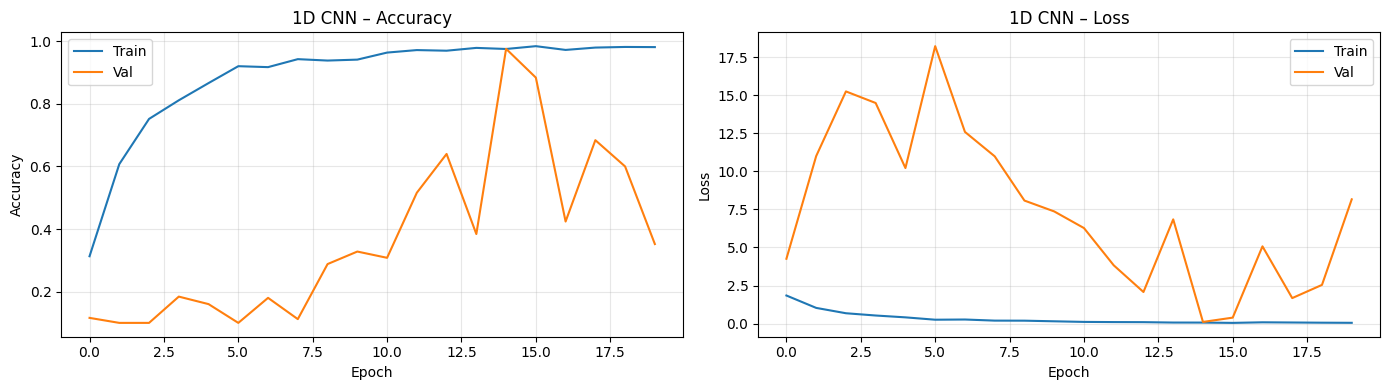


1D CNN  →  Test Loss: 0.0701  |  Test Accuracy: 98.40%


In [67]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(history_1d.history['accuracy'],     label='Train')
ax1.plot(history_1d.history['val_accuracy'], label='Val')
ax1.set_title('1D CNN – Accuracy'); ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history_1d.history['loss'],     label='Train')
ax2.plot(history_1d.history['val_loss'], label='Val')
ax2.set_title('1D CNN – Loss'); ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

test_loss_1d, test_acc_1d = model_1d.evaluate(X_raw_test, y_test, verbose=0)
print(f"\n1D CNN  →  Test Loss: {test_loss_1d:.4f}  |  Test Accuracy: {test_acc_1d*100:.2f}%")

Model                   Test Loss  Test Accuracy
2D CNN (MFCC)              0.0849         98.80%
1D CNN (Raw Audio)         0.0701         98.40%


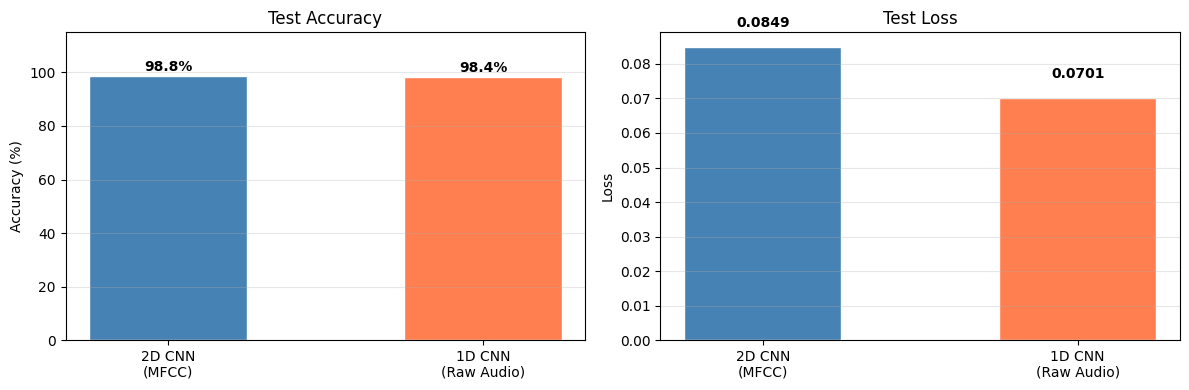

In [68]:
print("=" * 48)
print(f"{'Model':<22} {'Test Loss':>10}  {'Test Accuracy':>13}")
print("=" * 48)
print(f"{'2D CNN (MFCC)':<22} {test_loss_2d:>10.4f}  {test_acc_2d*100:>12.2f}%")
print(f"{'1D CNN (Raw Audio)':<22} {test_loss_1d:>10.4f}  {test_acc_1d*100:>12.2f}%")
print("=" * 48)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

models = ['2D CNN\n(MFCC)', '1D CNN\n(Raw Audio)']
accs   = [test_acc_2d * 100, test_acc_1d * 100]
losses = [test_loss_2d, test_loss_1d]
colors = ['steelblue', 'coral']

bars = ax1.bar(models, accs, color=colors, edgecolor='white', width=0.5)
for bar, a in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{a:.1f}%', ha='center', va='bottom', fontweight='bold')
ax1.set_ylim(0, 115); ax1.set_title('Test Accuracy')
ax1.set_ylabel('Accuracy (%)'); ax1.grid(axis='y', alpha=0.3)

bars2 = ax2.bar(models, losses, color=colors, edgecolor='white', width=0.5)
for bar, l in zip(bars2, losses):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{l:.4f}', ha='center', va='bottom', fontweight='bold')
ax2.set_title('Test Loss')
ax2.set_ylabel('Loss'); ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

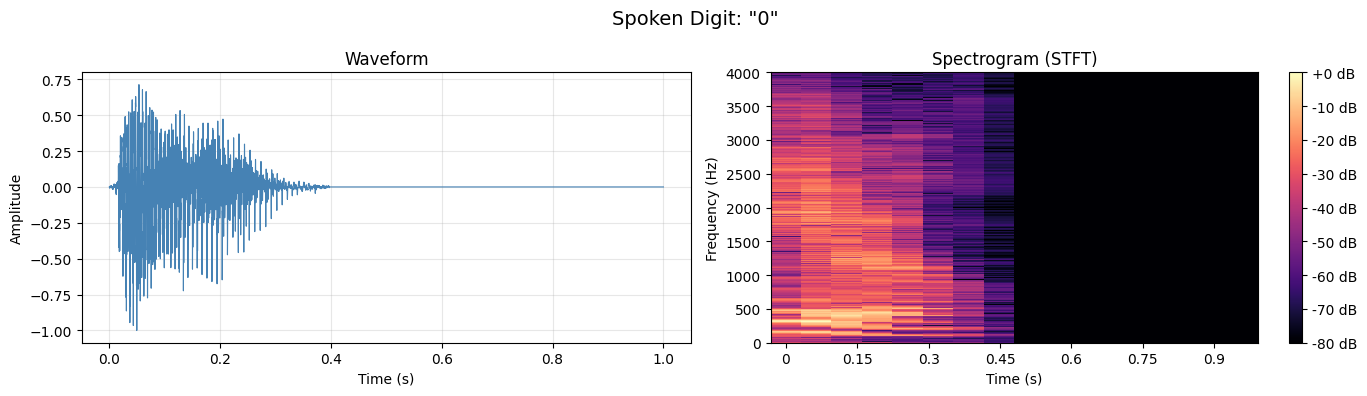

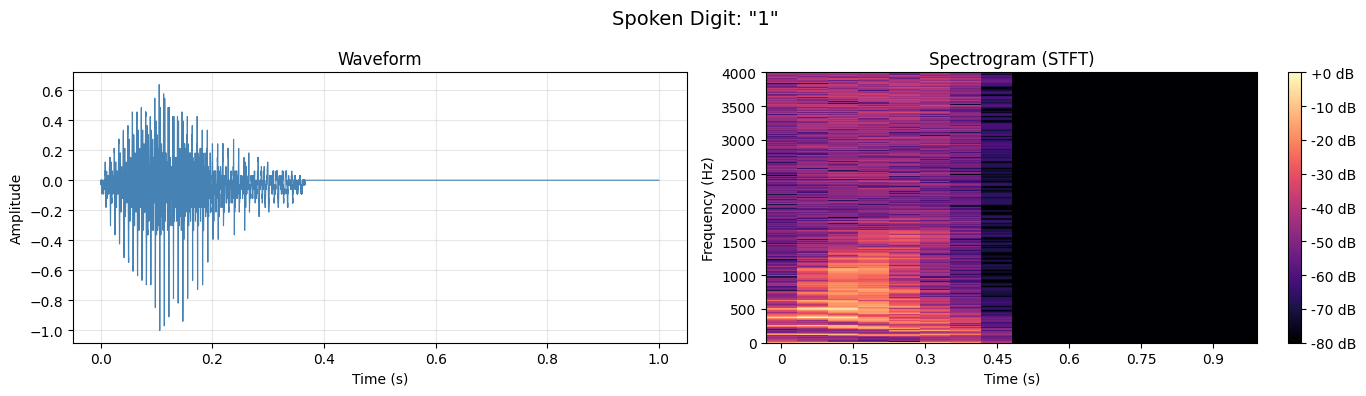

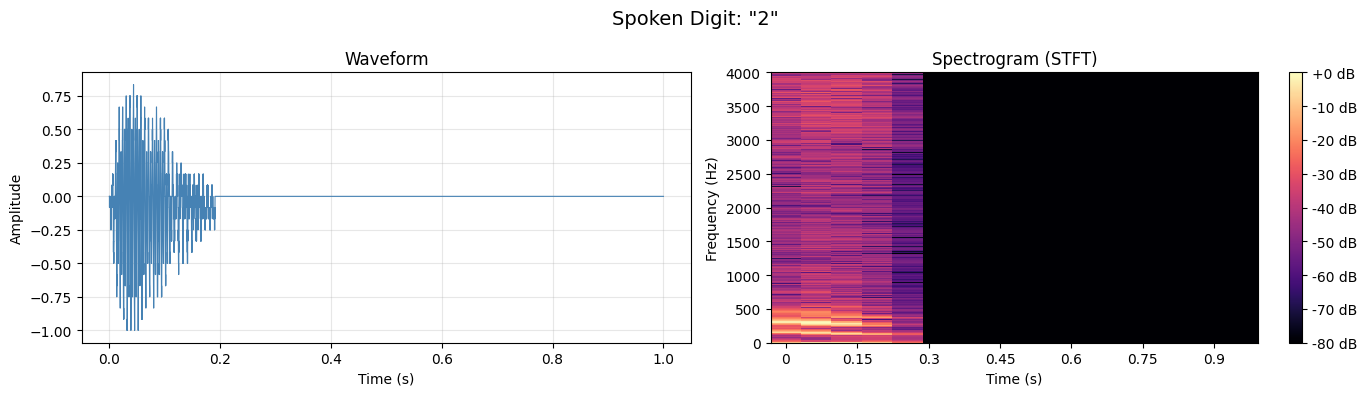

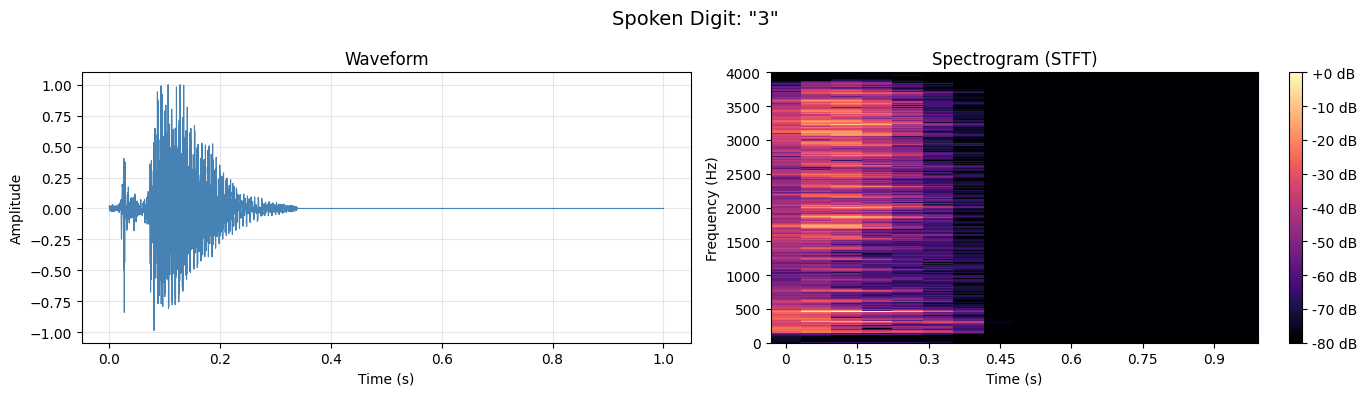

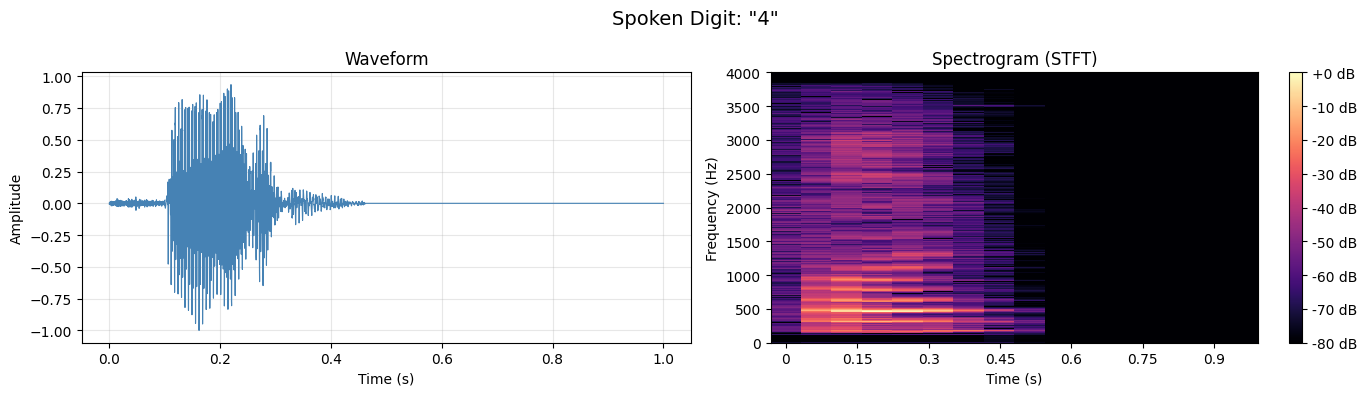

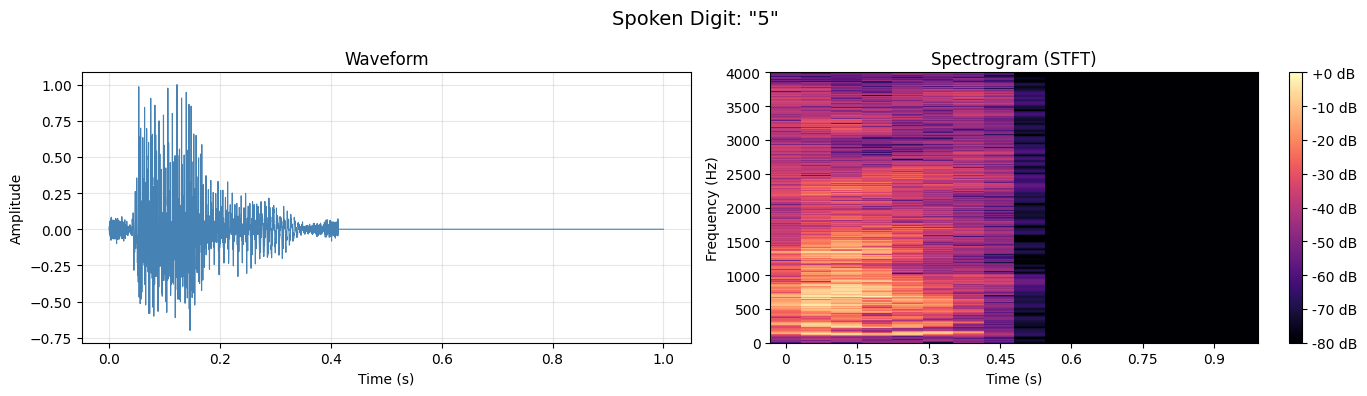

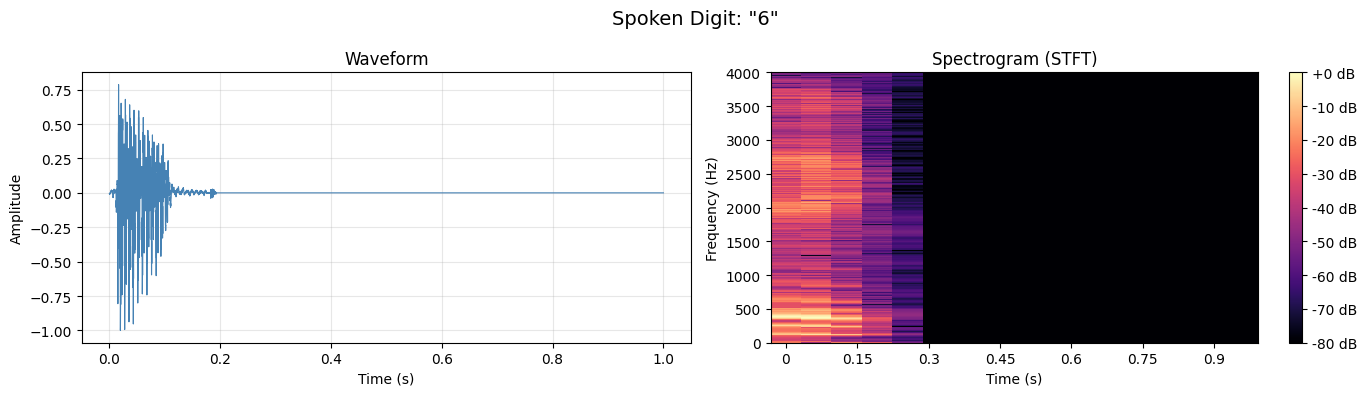

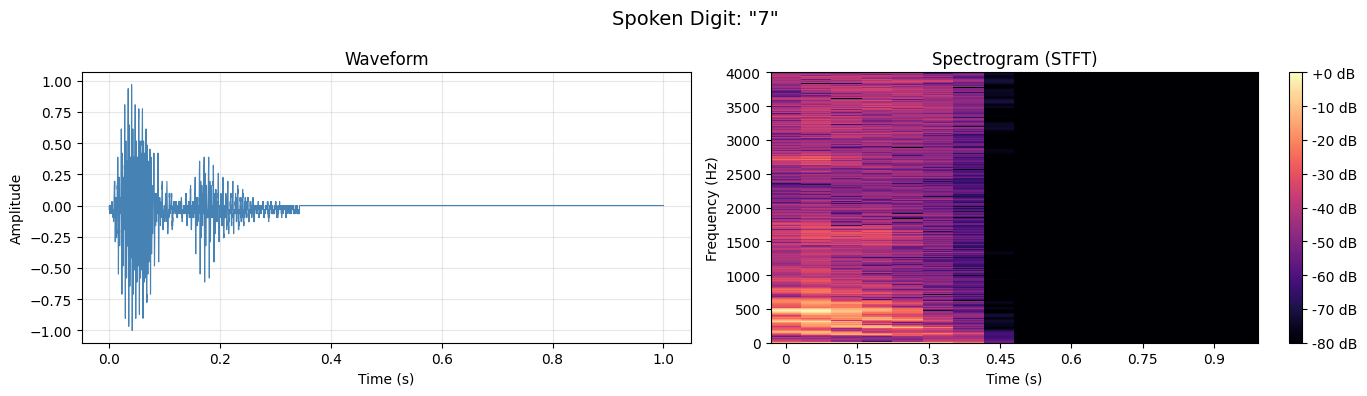

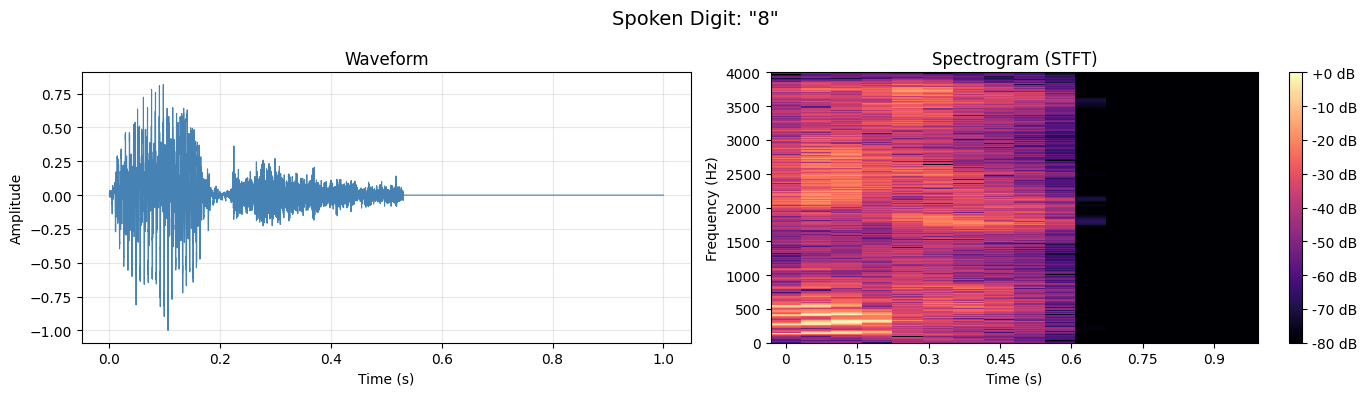

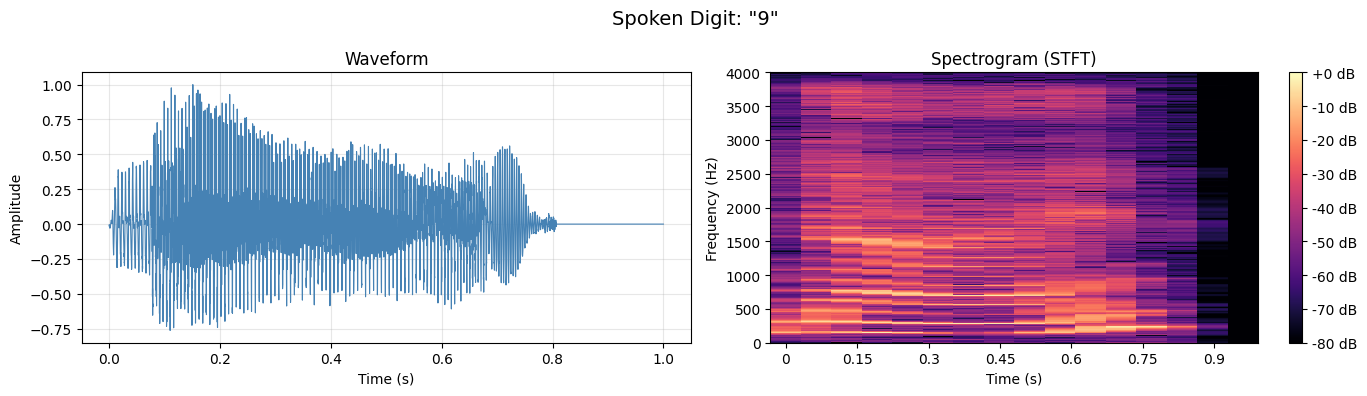

In [69]:
def plot_spectrogram(audio_1d, label, sr=8000):
    """Plot waveform + STFT spectrogram side by side for one audio sample."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'Spoken Digit: "{label}"', fontsize=14)

    # ── Waveform ──────────────────────────────────────────────────────────
    t = np.linspace(0, len(audio_1d) / sr, len(audio_1d))
    axes[0].plot(t, audio_1d, color='steelblue', linewidth=0.8)
    axes[0].set_title('Waveform')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Amplitude')
    axes[0].grid(alpha=0.3)

    # ── Spectrogram (STFT) ────────────────────────────────────────────────
    D    = librosa.stft(audio_1d)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    img  = librosa.display.specshow(
        S_db, sr=sr,
        x_axis='time', y_axis='hz',
        ax=axes[1], cmap='magma'
    )
    axes[1].set_title('Spectrogram (STFT)')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Frequency (Hz)')
    fig.colorbar(img, ax=axes[1], format='%+2.0f dB')

    plt.tight_layout()
    plt.show()


# Plot one example per digit (from the full, pre-split, normalised array)
for digit in range(10):
    idx = np.where(y == digit)[0][0]
    plot_spectrogram(X_raw[idx], label=digit)